# Session 4 — Quantifying Flow: Capacity & Cycle Time

**Course:** Decision Modelling — Simulation Part
**Session:** 4 of 12 (simulation portion)

## Learning objectives

By the end of this session you should be able to:

- State and apply **Little's Law** (`L = TH x W`) to relate WIP, throughput, and cycle time
- Compute **capacity** and **utilization** for a stage or resource, and identify the **bottleneck** in a multi-stage process
- Put precise numbers on the qualitative process map you built in Session 1

## Where this session fits

- **Looking back:** Session 1 introduced WIP, throughput (TH), and cycle time (CT) intuitively, alongside a qualitative process map (entities, resources, events). Session 3 modeled **static, one-shot** decisions with Monte Carlo — a single order quantity, a single realized demand, done.
- **Today:** many real operations aren't one-shot decisions at all — they're **flows** that run continuously: orders arrive, jobs queue at machines, patients wait for doctors, work-in-process accumulates. We put exact numbers on the Session 1 process map: how much capacity does each stage have, how utilized is it, and which stage limits the whole system's throughput?
- **Looking ahead:** everything today is still **deterministic averages** — we're not yet modeling randomness in *when* things happen. Session 5 adds that missing piece via queueing theory. From Session 6 onward, Discrete-Event Simulation lets us model flow systems this precise *and* stochastic, without needing a closed-form formula for every case.



## Further reading (supplementary, not required)

- Hopp & Spearman, *Factory Physics* — the standard OSCM reference for flow, capacity, and bottleneck analysis; more depth than what's derived here.
- The Zara ("Zara's Secret for Fast Fashion") case is a good real-world illustration of flow/capacity thinking in a supply chain context.



## 1. Process flow analysis and Little's Law

Recall the flow vocabulary from Session 1: **WIP** (work in process, `L`), **throughput** (`TH`, the rate of completions), and **cycle time** (`CT` or `W`, time in the system). Session 1 only asked you to build intuition for these; today we make the relationship between them precise.

**Little's Law:**

```
L = TH x W
```

(Work-in-process = throughput x cycle time.)

What makes Little's Law remarkably useful is that it holds for **almost any stable system**, regardless of the arrival process, service time distribution, number of resources, or queue discipline — as long as the system is in steady state (not systematically growing or shrinking). This generality is exactly why it will be your go-to sanity check on *any* DES model's output later in the course: no matter how complex the SimPy model, `L`, `TH`, and `W` measured from its output must satisfy Little's Law. If they don't, something in your model or your measurement is wrong.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# A quick numerical illustration of Little's Law: any two of (L, TH, W) pin down the third.
TH = 12.0    # throughput, e.g. 12 orders completed per hour
W = 0.75     # cycle time, e.g. 0.75 hours (45 minutes) per order

L = TH * W
print(f"Throughput (TH): {TH} orders/hour")
print(f"Cycle time (W):  {W} hours")
print(f"Implied WIP (L) = TH x W = {L} orders in process, on average")

Throughput (TH): 12.0 orders/hour
Cycle time (W):  0.75 hours
Implied WIP (L) = TH x W = 9.0 orders in process, on average


## 2. Capacity, utilization, and the bottleneck

**Capacity** of a resource or process stage is the maximum sustainable throughput it can provide — e.g. a machine that takes 5 minutes per unit has a capacity of `60/5 = 12` units/hour, *if it were busy 100% of the time*.

**Utilization** compares actual throughput to capacity:

```
utilization = TH / capacity
```

A stage running at 95% utilization is close to its limit; one at 40% has slack. For a **multi-stage process** (several stages in sequence, each with its own capacity), a key result follows almost immediately:

- The system's maximum throughput is capped by its **slowest stage** — the **bottleneck**.
- Every other stage, by definition, has spare capacity relative to the bottleneck.
- Speeding up any stage *other* than the bottleneck does not increase overall system throughput — only speeding up the bottleneck does.

This is one of the highest-leverage ideas in operations management: before investing in capacity anywhere, find the bottleneck first.



### Worked example: a 3-stage order fulfillment process

An order fulfillment process has three sequential stages: **pick**, **pack**, and **ship prep**. Each stage's processing time per order (in minutes) and number of parallel workers/stations is given below.



In [2]:
stages = pd.DataFrame({
    'stage': ['Pick', 'Pack', 'Ship prep'],
    'processing_time_min': [4.0, 6.0, 2.5],   # average time per order at that stage
    'n_stations': [2, 2, 1],                   # parallel stations/workers at that stage
})

# Capacity of a stage (orders/hour) = n_stations / (processing_time_min / 60)
stages['capacity_per_hour'] = stages['n_stations'] / (stages['processing_time_min'] / 60)

print(stages)

bottleneck = stages.loc[stages['capacity_per_hour'].idxmin()]
print(f"\nBottleneck stage: {bottleneck['stage']} "
      f"(capacity = {bottleneck['capacity_per_hour']:.2f} orders/hour)")
print(f"This caps the whole process's maximum throughput at "
      f"{bottleneck['capacity_per_hour']:.2f} orders/hour, no matter how fast Pick or the other stages run.")

       stage  processing_time_min  n_stations  capacity_per_hour
0       Pick                  4.0           2               30.0
1       Pack                  6.0           2               20.0
2  Ship prep                  2.5           1               24.0

Bottleneck stage: Pack (capacity = 20.00 orders/hour)
This caps the whole process's maximum throughput at 20.00 orders/hour, no matter how fast Pick or the other stages run.


       stage  capacity_per_hour  utilization
0       Pick               30.0        0.667
1       Pack               20.0        1.000
2  Ship prep               24.0        0.833


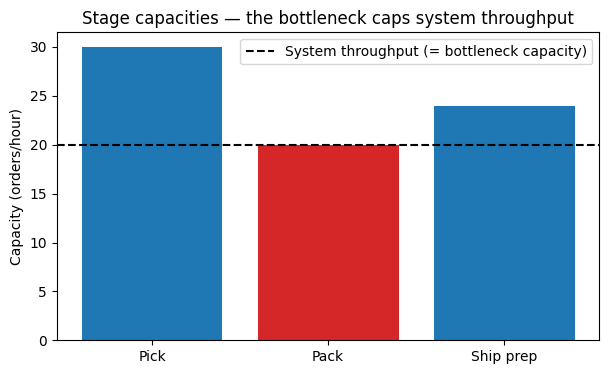

In [3]:
# Utilization of each stage, GIVEN the system is actually running at the bottleneck's throughput
system_throughput = bottleneck['capacity_per_hour']
stages['utilization'] = system_throughput / stages['capacity_per_hour']

print(stages[['stage', 'capacity_per_hour', 'utilization']].round(3))

plt.figure(figsize=(7, 4))
plt.bar(stages['stage'], stages['capacity_per_hour'], color=['tab:red' if s == bottleneck['stage'] else 'tab:blue' for s in stages['stage']])
plt.axhline(system_throughput, color='black', linestyle='--', label='System throughput (= bottleneck capacity)')
plt.ylabel('Capacity (orders/hour)')
plt.title('Stage capacities — the bottleneck caps system throughput')
plt.legend()
plt.show()

Now let's connect this back to Little's Law. Suppose we track the **cycle time** through the whole process (pick + pack + ship prep, plus any waiting) for orders processed at this system throughput.



In [4]:
# Suppose we observe (e.g. from a time study) that an order spends, on average,
# 9 minutes actually being worked on across the three stages, plus 6 minutes waiting
# between/at stages due to congestion -- for a total cycle time:
cycle_time_hours = (9 + 6) / 60

wip = system_throughput * cycle_time_hours
print(f"System throughput: {system_throughput:.2f} orders/hour")
print(f"Cycle time: {cycle_time_hours*60:.1f} minutes ({cycle_time_hours:.3f} hours)")
print(f"Implied WIP (Little's Law): {wip:.2f} orders in the system, on average")

System throughput: 20.00 orders/hour
Cycle time: 15.0 minutes (0.250 hours)
Implied WIP (Little's Law): 5.00 orders in the system, on average


Notice the **6 minutes of waiting** on top of the 9 minutes of actual processing — this is exactly what a deterministic, average-only view like today's can't explain on its own. Waiting emerges from **variability** (orders don't arrive evenly spaced, processing times aren't identical every time) interacting with **utilization** (stages running close to capacity leave little slack to absorb that variability). That interaction is precisely what Session 5's queueing theory quantifies — and what Session 1 already hinted at when it said WIP, TH, and CT "move together."



## Exercise (guided): finding and relieving the bottleneck

A 4-stage inspection line has the following stage data. Management is considering adding **one more worker to a single stage** (their choice) and wants to know which stage gives the biggest throughput improvement.

| Stage | Processing time (min/unit) | Current workers |
|---|---|---|
| Receive | 3.0 | 1 |
| Inspect | 8.0 | 3 |
| Test | 5.0 | 2 |
| Log & release | 2.0 | 1 |

Your task:

1. Build a DataFrame like the worked example above and compute each stage's capacity and the current bottleneck
2. For each stage, compute what the system's bottleneck capacity *would become* if you added one worker to that stage only (recompute that stage's capacity with `n_stations + 1`, leave the others unchanged, and find the new minimum across all four stages)
3. Identify which single addition gives the largest increase in system throughput
4. State, in a sentence, why adding a worker to a **non-bottleneck** stage might give zero improvement



In [5]:
# EXERCISE
inspection_stages = pd.DataFrame({
    'stage': ['Receive', 'Inspect', 'Test', 'Log & release'],
    'processing_time_min': [3.0, 8.0, 5.0, 2.0],
    'n_stations': [1, 3, 2, 1],
})

# TODO: compute capacity_per_hour for each stage and find the current bottleneck

# TODO: for each stage, compute the system throughput if that stage alone got +1 worker
#       (hint: copy the capacities, bump one stage's n_stations by 1, recompute that
#        stage's capacity, then take the min across all four stages)

# TODO: report which stage to add a worker to for the biggest throughput gain, and by how much

<details>
<summary>Solution (click to expand)</summary>

```python
# SOLUTION
inspection_stages['capacity_per_hour'] = (
    inspection_stages['n_stations'] / (inspection_stages['processing_time_min'] / 60)
)
current_bottleneck_cap = inspection_stages['capacity_per_hour'].min()
print(inspection_stages)
print(f"\nCurrent bottleneck capacity: {current_bottleneck_cap:.2f} orders/hour")

improvements = []
for i, row in inspection_stages.iterrows():
    trial = inspection_stages.copy()
    trial.loc[i, 'n_stations'] += 1
    trial.loc[i, 'capacity_per_hour'] = trial.loc[i, 'n_stations'] / (trial.loc[i, 'processing_time_min'] / 60)
    new_bottleneck_cap = trial['capacity_per_hour'].min()
    improvements.append({
        'stage_upgraded': row['stage'],
        'new_bottleneck_capacity': new_bottleneck_cap,
        'improvement': new_bottleneck_cap - current_bottleneck_cap
    })

improvements_df = pd.DataFrame(improvements).sort_values('improvement', ascending=False)
print(improvements_df.round(3))

best = improvements_df.iloc[0]
print(f"\nBest choice: add a worker to '{best['stage_upgraded']}', "
      f"improving system throughput by {best['improvement']:.2f} orders/hour.")
```

Adding a worker to a stage that is *not* the current bottleneck typically shows **zero or near-zero** improvement in `improvements_df`, because the system-wide minimum is still set by the original bottleneck — you've added slack somewhere that already had slack.
</details>



### Discussion questions

1. In the worked example, all processing times and worker counts were treated as fixed averages — no randomness anywhere. What real-world features of order fulfillment might make actual throughput *lower* than the deterministic capacity number, even with the same average processing times?
2. Little's Law held exactly in Section 1's numeric example because we picked consistent numbers. In a real system, would you expect `L`, `TH`, and `W` measured from real data to satisfy `L = TH x W` *exactly*? What would make it only hold approximately, or only "on average over time"?
3. This session assumed we already know average processing times and worker counts. Where would those numbers come from in practice? (Hint: revisit Session 2.)



## Wrap-up

Today we:

- Made Little's Law precise (`L = TH x W`) and established why its generality makes it a universal sanity check for simulation output
- Defined capacity and utilization for a process stage, and identified the **bottleneck** as the stage that caps system-wide throughput
- Worked a multi-stage example end to end: capacities → bottleneck → system throughput → implied WIP via Little's Law
- Practiced identifying which capacity investment actually helps, and which doesn't

**Next session:** Queueing Theory for Simulation — everything today assumed fixed, average processing and arrival times. Real systems are **stochastic**: arrivals and service times vary randomly around those averages, which is exactly what produces the waiting time we saw sneak into the worked example above. Queueing theory gives us closed-form formulas for simple stochastic flow systems — and, just as importantly, tells us exactly where closed-form breaks down and simulation becomes necessary.

